In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
import os 

# SETUP FOLDER PENYIMPANAN GAMBAR
# Membuat folder khusus untuk menyimpan hasil visualisasi dataset Glass
save_dir = '../output/figures/glass/'
os.makedirs(save_dir, exist_ok=True)
print(f"📂 Folder penyimpanan gambar siap di: {save_dir}")

📂 Folder penyimpanan gambar siap di: ../output/figures/glass/


In [3]:
dataset = pd.read_csv('../data/glass_clean.csv')
dataset.head()

,Refractive_Index,Sodium,Magnesium,Aluminum,Silicon,Potassium,Calcium,Barium,Iron,Tipe_Kaca
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,A
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,A
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,A
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,A
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,A


In [5]:
# ==========================================
# 2. PREPROCESSING TARGET (MULTI-CLASS ENCODING)
# ==========================================
target_col = 'Tipe_Kaca'

le = LabelEncoder()
dataset['Target_Encoded'] = le.fit_transform(dataset[target_col])

print("\n--- Mapping Target (Kelas Asli -> Angka Baru) ---")
for i, item in enumerate(le.classes_):
    print(f"Kelas Asli {item}  -->  {i}")

print("\nDistribusi Target:")
print(dataset['Target_Encoded'].value_counts().sort_index())


--- Mapping Target (Kelas Asli -> Angka Baru) ---
Kelas Asli A  -->  0
Kelas Asli B  -->  1
Kelas Asli C  -->  2
Kelas Asli E  -->  3
Kelas Asli F  -->  4
Kelas Asli G  -->  5

Distribusi Target:
Target_Encoded
0    69
1    76
2    17
3    13
4     9
5    29
Name: count, dtype: int64


In [6]:
# ==========================================
# 3. NORMALISASI FITUR (MINMAX SCALER)
# ==========================================
# Pisahkan X (Fitur) dan y (Target)
X = dataset.drop([target_col, 'Target_Encoded'], axis=1)
y = dataset['Target_Encoded']

# Inisialisasi Scaler
scaler = MinMaxScaler()

# Lakukan Scaling
X_scaled = scaler.fit_transform(X)

# Kembalikan ke DataFrame
X_scaled_dataset = pd.DataFrame(X_scaled, columns=X.columns)

# Cek Hasil Scaling
print("\n--- Output: 5 Data Teratas Setelah Normalisasi ---")
print(X_scaled_dataset.head())

print("\n--- Statistik Normalisasi (Cek Min=0 & Max=1) ---")
print(X_scaled_dataset.describe().loc[['min', 'max']])


--- Output: 5 Data Teratas Setelah Normalisasi ---
   Refractive_Index    Sodium  Magnesium  Aluminum   Silicon  Potassium  \
0          0.432836  0.437594   1.000000  0.252336  0.351786   0.009662   
1          0.283582  0.475188   0.801782  0.333333  0.521429   0.077295   
2          0.220808  0.421053   0.790646  0.389408  0.567857   0.062802   
3          0.285777  0.372932   0.821826  0.311526  0.500000   0.091787   
4          0.275241  0.381955   0.806236  0.295950  0.583929   0.088567   

    Calcium  Barium  Iron  
0  0.308550     0.0   0.0  
1  0.223048     0.0   0.0  
2  0.218401     0.0   0.0  
3  0.259294     0.0   0.0  
4  0.245353     0.0   0.0  

--- Statistik Normalisasi (Cek Min=0 & Max=1) ---
     Refractive_Index  Sodium  Magnesium  Aluminum  Silicon  Potassium  \
min               0.0     0.0        0.0       0.0      0.0        0.0   
max               1.0     1.0        1.0       1.0      1.0        1.0   

     Calcium  Barium  Iron  
min      0.0     0.0   0.0

✅ Gambar berhasil disimpan sebagai 'Feature_Relevance_HD.png'


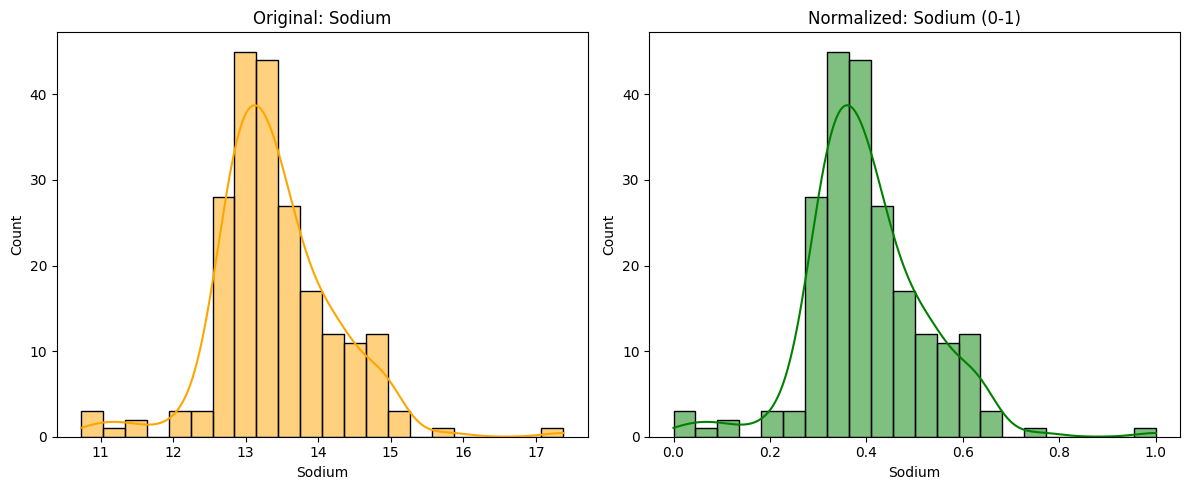

In [ ]:
# ==========================================
# 4. VISUALISASI VALIDASI (Before vs After)
# ==========================================
# Kita cek fitur yang outliernya banyak tadi, misal 'Barium' atau 'Sodium'
feature_to_check = 'Sodium' # Bisa ganti 'Barium'

plt.figure(figsize=(12, 5))

# Plot Sebelum
plt.subplot(1, 2, 1)
sns.histplot(dataset[feature_to_check], kde=True, color='orange')
plt.title(f'Original: {feature_to_check}')

# Plot Sesudah
plt.subplot(1, 2, 2)
sns.histplot(X_scaled_dataset[feature_to_check], kde=True, color='green')
plt.title(f'Normalized: {feature_to_check} (0-1)')

plt.tight_layout()
plt.show()


=== ANALISIS FITUR ===

[1] Feature Relevance (Korelasi ke Tipe Kaca):
Magnesium           0.727268
Aluminum            0.589328
Barium              0.577457
Sodium              0.512761
Iron                0.186207
Refractive_Index    0.164371
Silicon             0.145570
Name: Target_Encoded, dtype: float64


C:\Users\harto\AppData\Local\Temp\ipykernel_11096\1658988607.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')


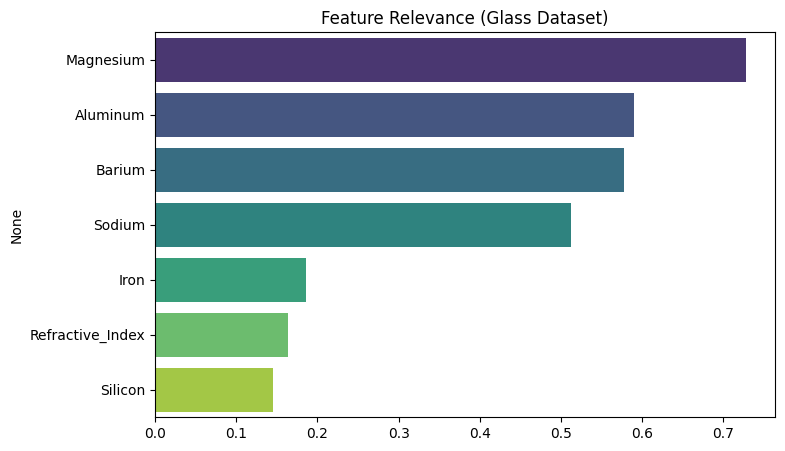

In [22]:
# ==========================================
# 5. FEATURE ANALYSIS RELEVANSI
# ==========================================
print("\n=== ANALISIS FITUR ===")

# Gabung sementara untuk cek korelasi
df_analysis = pd.concat([X_scaled_dataset, y], axis=1)

# A. FEATURE RELEVANCE
# --------------------
correlation_matrix = df_analysis.corr()
target_corr = correlation_matrix['Target_Encoded'].drop('Target_Encoded').abs().sort_values(ascending=False)

print("\n[1] Feature Relevance (Korelasi ke Tipe Kaca):")
print(target_corr)

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')
plt.title('Feature Relevance (Glass Dataset)')
plt.show()

In [13]:
# ==========================================
# EKSEKUSI PENGHAPUSAN FITUR LEMAH (RELEVANCE)
# ==========================================
print("\n--- EKSEKUSI DROP FITUR (RELEVANCE < 0.05) ---")

# Daftar fitur yang divonis 'Lemah' berdasarkan data kamu:
# 1. Calcium   (0.007) -> Sangat rendah
# 2. Potassium (0.028) -> Sangat rendah

features_to_drop = ['Calcium', 'Potassium']

# Cek apakah kolom masih ada sebelum didrop (biar tidak error kalau dijalankan 2x)
cols_exist = [col for col in features_to_drop if col in X_scaled_dataset.columns]

if len(cols_exist) > 0:
    X_scaled_dataset = X_scaled_dataset.drop(columns=cols_exist)
    print(f"Berhasil menghapus fitur lemah: {cols_exist}")
else:
    print("Fitur target sudah tidak ada (mungkin sudah terhapus sebelumnya).")
print(f"Sisa Fitur ({len(X_scaled_dataset.columns)}):")
print(X_scaled_dataset.columns.tolist())


--- EKSEKUSI DROP FITUR (RELEVANCE < 0.05) ---
Fitur target sudah tidak ada (mungkin sudah terhapus sebelumnya).
Sisa Fitur (7):
['Refractive_Index', 'Sodium', 'Magnesium', 'Aluminum', 'Silicon', 'Barium', 'Iron']


✅ Gambar berhasil disimpan sebagai 'Feature_Relevance_HD.png'


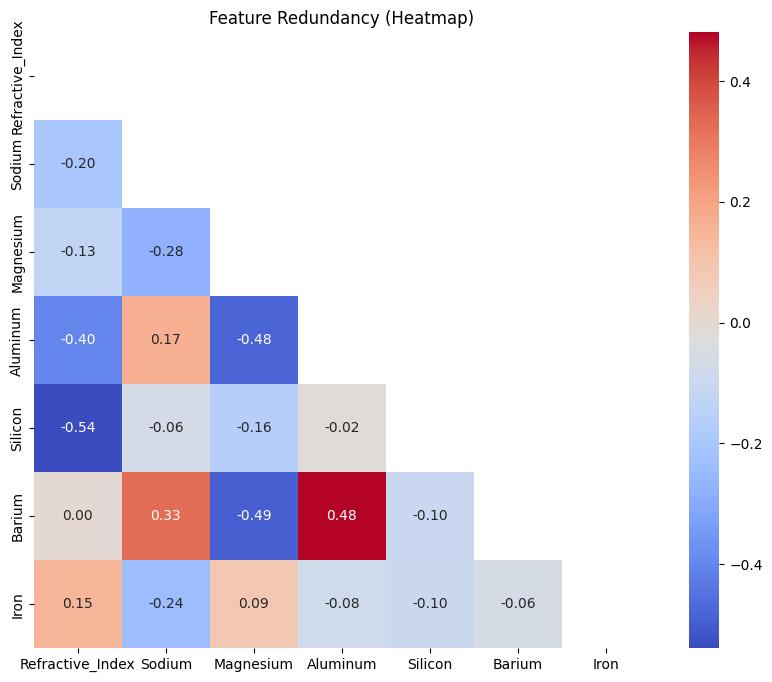


[2] Cek Redundansi (> 0.8):
Tidak ditemukan fitur duplikat yang parah.


In [ ]:
# ==========================================
# 5. FEATURE ANALYSIS REDUNDANCY
# ==========================================
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(X_scaled_dataset.corr(), dtype=bool))
sns.heatmap(X_scaled_dataset.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Redundancy (Heatmap)')
plt.show()

# Cek Redundansi Otomatis
threshold_redundancy = 0.8
redundant_pairs = []
features = X_scaled_dataset.columns
corr_matrix = X_scaled_dataset.corr().abs()

print(f"\n[2] Cek Redundansi (> {threshold_redundancy}):")
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if corr_matrix.iloc[i, j] > threshold_redundancy:
            pair = (features[i], features[j], corr_matrix.iloc[i, j])
            redundant_pairs.append(pair)

if len(redundant_pairs) > 0:
    print("DITEMUKAN FITUR REDUNDAN:")
    for f1, f2, score in redundant_pairs:
        print(f"- {f1} <--> {f2} (Corr: {score:.2f})")
else:
    print("Tidak ditemukan fitur duplikat yang parah.")

In [11]:
# ==========================================
# 7. SIMPAN DATA FINAL (GLASS DATASET)
# ==========================================
dataset_final = pd.concat([X_scaled_dataset, y], axis=1)
output_path = '../data/glass_normalized.csv'
dataset_final.to_csv(output_path, index=False)

print(f"SUKSES! File berhasil disimpan ke: {output_path}")
print(f"Dimensi Akhir: {dataset_final.shape} (Baris, Kolom)")
print("Daftar Kolom Final:")
print(dataset_final.columns.tolist())

print("\n--- SEMUA TAHAP PRE-PROCESSING SELESAI ---")

SUKSES! File berhasil disimpan ke: ../data/glass_normalized.csv
Dimensi Akhir: (213, 8) (Baris, Kolom)
Daftar Kolom Final:
['Refractive_Index', 'Sodium', 'Magnesium', 'Aluminum', 'Silicon', 'Barium', 'Iron', 'Target_Encoded']

--- SEMUA TAHAP PRE-PROCESSING SELESAI ---
